# Задание Lite — PyTorch

Создайте нейронную сеть, распознающую рукописные цифры. Используется база MNIST. Данные нормируются, создаётся и обучается сверточная сеть.

**Параметры модели:** минимум 2 сверточных слоя, полносвязные слои, слой подвыборки, нормализация и регуляризация.

**Гиперпараметры обучения:** функция ошибки — `CrossEntropyLoss`, оптимизатор — `Adam` с шагом обучения `0.001`, размер пакета — `128`, количество эпох — `15`.

В конце выводится график доли верных ответов на обучающей и проверочной выборках.


In [1]:
# Библиотеки

import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

try:
    from google.colab import files
except Exception:
    files = None

%matplotlib inline

# Выбор устройства. Если CUDA недоступна, используется процессор.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)


Устройство: cpu


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.37MB/s]


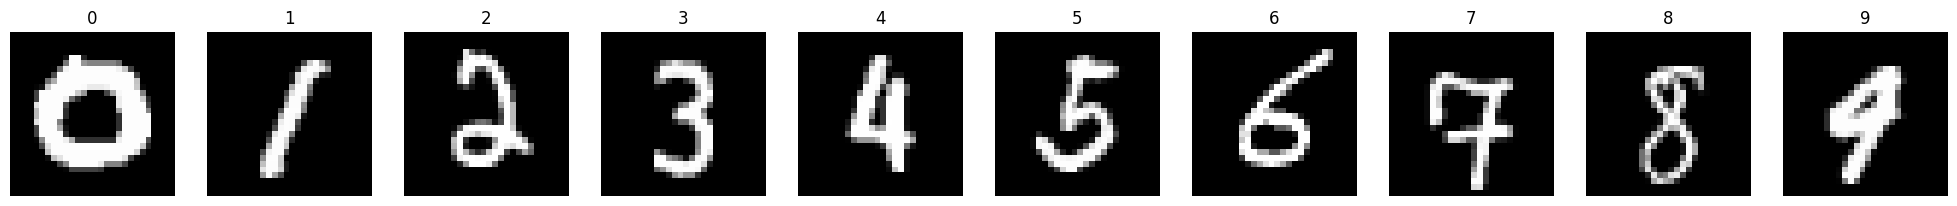

Размер обучающей выборки: 60000
Размер проверочной выборки: 10000
Форма одного изображения: torch.Size([1, 28, 28])
Пример метки класса: 5


In [2]:
# Загрузка и подготовка датасета MNIST

transform = transforms.Compose([
    transforms.ToTensor()   # перевод в тензор и нормирование значений пикселей в диапазон [0; 1]
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Отображение изображений каждого класса для ознакомления с датасетом
fig, axs = plt.subplots(1, 10, figsize=(25, 3))

for digit in range(10):
    indexes = np.where(train_dataset.targets.numpy() == digit)[0]
    index = random.choice(indexes)
    img = train_dataset.data[index].numpy()

    axs[digit].imshow(img, cmap='gray')
    axs[digit].set_title(str(digit))
    axs[digit].axis('off')

plt.show()

print('Размер обучающей выборки:', len(train_dataset))
print('Размер проверочной выборки:', len(test_dataset))
print('Форма одного изображения:', train_dataset[0][0].shape)
print('Пример метки класса:', train_dataset[0][1])


In [3]:
# Модель и класс для обучения / распознавания

class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Первый сверточный слой
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)       # нормализация
        self.dropout_conv = nn.Dropout2d(0.5) # регуляризация

        # Второй сверточный слой
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Слой подвыборки
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)

        # После MaxPool2d(3, 3): 28x28 превращается в 9x9
        self.fc1 = nn.Linear(64 * 9 * 9, 128)
        self.dropout_fc = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout_conv(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout_fc(x)
        x = self.fc2(x)

        # Softmax здесь не нужен: CrossEntropyLoss принимает сырые выходы модели
        return x


class RecogNum:
    def __init__(self, epochs=15, batch_size=128, learning_rate=0.001):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.device = device

        self.model = None
        self.history = None

        self.train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True
        )

        self.test_loader = DataLoader(
            test_dataset,
            batch_size=self.batch_size,
            shuffle=False
        )

    # Создание модели
    def create_model(self):
        return DigitCNN().to(self.device)

    # Оценка модели на выборке
    def evaluate_loader(self, data_loader, criterion):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in data_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item() * images.size(0)
                predicted = torch.argmax(outputs, dim=1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_loss = total_loss / total
        accuracy = correct / total

        return avg_loss, accuracy

    # Обучение модели
    def train_model(self):
        self.model = self.create_model()

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(
            self.model.parameters(),
            lr=self.learning_rate
        )

        self.history = {
            'loss': [],
            'accuracy': [],
            'val_loss': [],
            'val_accuracy': []
        }

        for epoch in range(self.epochs):
            self.model.train()

            train_loss_sum = 0.0
            train_correct = 0
            train_total = 0

            for images, labels in self.train_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss_sum += loss.item() * images.size(0)
                predicted = torch.argmax(outputs, dim=1)

                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()

            train_loss = train_loss_sum / train_total
            train_accuracy = train_correct / train_total

            val_loss, val_accuracy = self.evaluate_loader(self.test_loader, criterion)

            self.history['loss'].append(train_loss)
            self.history['accuracy'].append(train_accuracy)
            self.history['val_loss'].append(val_loss)
            self.history['val_accuracy'].append(val_accuracy)

            print(
                f"Эпоха {epoch + 1}/{self.epochs} - "
                f"loss: {train_loss:.4f} - "
                f"accuracy: {train_accuracy:.4f} - "
                f"val_loss: {val_loss:.4f} - "
                f"val_accuracy: {val_accuracy:.4f}"
            )

        test_loss, test_accuracy = self.evaluate_loader(self.test_loader, criterion)

        # Сохранение обученной модели
        torch.save(self.model.state_dict(), 'recog_num_model_pytorch.pth')

        return self.history, test_loss, test_accuracy

    # Загрузка изображения
    def upload_pic(self):
        if files is None:
            raise RuntimeError('Загрузка файла через files.upload() доступна в Google Colab.')

        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        print('Загружен файл:', filename)

        # Открытие изображения в сером формате
        img = Image.open(filename).convert('L')
        img_array = np.array(img)

        plt.figure(figsize=(4, 4))
        plt.imshow(img_array, cmap='gray')
        plt.title('Исходное изображение')
        plt.axis('off')
        plt.show()

        # Определение фона по краям
        border = np.concatenate([
            img_array[0, :],
            img_array[-1, :],
            img_array[:, 0],
            img_array[:, -1]
        ])

        # Если фон светлый — инвертируем изображение
        if border.mean() > 127:
            img_array = 255 - img_array

        # Убираем слабый шум
        img_array[img_array < 20] = 0

        # Находим область цифры
        coords = np.argwhere(img_array > 20)
        if len(coords) == 0:
            raise ValueError('Цифра не найдена')

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        # Обрезаем только цифру
        img_array = img_array[y_min:y_max + 1, x_min:x_max + 1]

        # Вписываем в квадрат
        h, w = img_array.shape
        size = max(h, w) + 12
        square = np.zeros((size, size), dtype=np.uint8)

        y_offset = (size - h) // 2
        x_offset = (size - w) // 2
        square[y_offset:y_offset + h, x_offset:x_offset + w] = img_array

        # Масштабируем до 28x28
        img_final = Image.fromarray(square).resize((28, 28))
        img_final = np.array(img_final).astype('float32') / 255.0

        plt.figure(figsize=(4, 4))
        plt.imshow(img_final, cmap='gray', interpolation='nearest')
        plt.title('То, что идет в сеть')
        plt.axis('off')
        plt.show()

        # Формат PyTorch: batch, channels, height, width
        img_tensor = torch.tensor(img_final, dtype=torch.float32)
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)

        print('Форма для подачи в сеть:', img_tensor.shape)

        return img_tensor

    # Распознавание цифры
    def predict_num(self):
        num_img = self.upload_pic().to(self.device)

        # Если модель ещё не создана, загружаем сохранённые веса
        if self.model is None:
            self.model = self.create_model()
            self.model.load_state_dict(
                torch.load('recog_num_model_pytorch.pth', map_location=self.device)
            )

        self.model.eval()

        with torch.no_grad():
            outputs = self.model(num_img)
            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]
            predicted_digit = int(np.argmax(probabilities))

        print('Распознанная цифра:', predicted_digit)
        print('Вероятности по классам:')

        for i in range(10):
            print(f'{i}: {probabilities[i]:.6f}')

        return predicted_digit

    # Отображение графиков обучения и ошибки
    def show_graph(self):
        if self.history is None:
            raise ValueError('История обучения пустая. Сначала обучите модель.')

        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(self.history['accuracy'], label='Обучающая выборка')
        plt.plot(self.history['val_accuracy'], label='Проверочная выборка')
        plt.xlabel('Эпоха')
        plt.ylabel('Доля верных ответов')
        plt.title('График точности')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(self.history['loss'], label='Ошибка обучения')
        plt.plot(self.history['val_loss'], label='Ошибка проверки')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.title('График ошибки')
        plt.legend()
        plt.grid(True)

        plt.show()


In [4]:
# Обучение модели

model = RecogNum(epochs=15, batch_size=128, learning_rate=0.001)
history, loss, accuracy = model.train_model()

print('Ошибка на проверочной выборке:', loss)
print('Точность на проверочной выборке:', accuracy)


Эпоха 1/15 - loss: 0.2351 - accuracy: 0.9279 - val_loss: 0.0545 - val_accuracy: 0.9822


KeyboardInterrupt: 

In [ ]:
# Графики обучения

model.show_graph()
